## Classification Intuition
###### (Intuition in ML/math/engineering means "A clear mental model of how something works, without formulas or code details")

| Task           | Output                      |
| -------------- | --------------------------- |
| Regression     | Number (price, score)       |
| Classification | Category (yes/no, spam/ham) |


Classification still predicts numbers

But:

- Numbers represent probabilities

- We convert probabilities → classes

Example:

- 0.87 → Yes
- 0.12 → No

### Decision Boundary

A decision boundary is the line/curve that separates classes

![image.png](Images/decision-boundary.png)

- Points on one side → Class A

- Points on other side → Class B

## Logistic Regression

### Why Linear Regression fails for classification

Suppose you want:

- 0 = No

- 1 = Yes

Linear regression can predict:

0.4, 1.3, 2.1


❌ These make no sense as classes.

We need:

- Output between 0 and 1

- Interpretable as probability

### The key idea: Probability first, class later

Logistic Regression does this:

- Predicts a probability (0 to 1)

- Converts it to a class using a threshold

Example:

- P = 0.82 → Class 1
- P = 0.31 → Class 0


Default threshold = 0.5

### Sigmoid function (forcing output between 0 and 1)

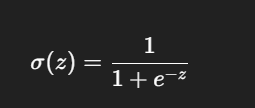

z=mx+c <br>
(Same linear equation)

- Input: any number

- Output: always between 0 and 1
<br><br>

- Linear Regression → outputs z

- Logistic Regression → passes z through sigmoid

| Aspect        | Logistic Regression      |
| ------------- | ------------------------ |
| Output        | Probability (0–1)        |
| Final result  | Class (0 / 1)            |
| Boundary      | Straight line (or plane) |
| Core function | Sigmoid                  |


## Logistic Regression — CODE + INTUITION

### 1. Simple binary dataset

Predict whether a student passes (1) or fails (0) based on study hours.

In [1]:
import pandas as pd
import seaborn as sns

# data = {
#     "hours": [1, 2, 3, 4, 5, 6, 7, 8],
#     "pass":  [0, 0, 0, 0, 1, 1, 1, 1]
# }
# df = pd.DataFrame(data)

df = sns.load_dataset("tips")


### 2. Split into X and y

In [2]:
# X = df[["hours"]]
# y = df["pass"]

X = df[["total_bill"]]
y = df["sex"]

### 3. Train-Test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### 4. Train Logistic Regression 

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 5. Make Predictions

##### Class predictions (0 or 1)

In [5]:
y_pred = model.predict(X_test)

##### Probability predictions

In [6]:
y_prob = model.predict_proba(X_test)

##### Convert probability → class

- P ≥ 0.5 → class 1
- P < 0.5 → class 0

Scikit-learn does this automatically in predict().

##### Evaluate with Accuracy

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6885245901639344


## Accuracy vs Precision vs Recall

### Problem with relying only on accuracy

Problem: Disease detection

- 1,000 people

- 990 healthy

- 10 sick

Model predicts:

- Everyone is healthy

Accuracy:

990 / 1000 = 99%


But the model found ZERO sick people which is useless

This is why accuracy alone lies.

### Confusion Matrix (Intuition)

|                | Predicted NEGATIVE | Predicted POSITIVE | |
| -------------- | ------------ | ------------- |-|
| **Actual NEGATIVE**  | **TN**           | FP            | *Specificity* |
| **Actual POSTITIVE** | FN           | **TP**            | *Recall* |
| *Error Rate*         | *Negative Predictive Value* | *Precision* | *Accuracy* |


- TP → correctly predicted YES

- TN → correctly predicted NO

- FP → false alarm

- FN → missed detection

### Accuracy

Total Correct Predictions

Accuracy = $\frac{TP + TN}{Total}$

- Good when classes are balanced

- Misleading when data is imbalanced

### Precision (how careful the model is)

Of all predicted Positive, how many were actually Positive?

Precision = $\frac{TP}{TP + FP}$

📌 High precision = few false alarms

Example use:

- Spam detection (don’t mark important mail as spam)

### Recall (how complete the model is)

Of all actual Positive, how many did we predict correctly?

Recall = $\frac{TP}{TP + FN}$

📌 High recall = few missed positives

Example use:

- Disease detection

- Fraud detection

### Difference between Precision and Recall

- Precision cares about FALSE POSITIVES
- Recall cares about FALSE NEGATIVES

#### Concrete example (numbers make this click)

Imagine:

- 100 emails

- 10 are spam

- 90 are normal

Model output:

- flags 5 emails as spam

- 4 are actually spam

- 1 is not spam

So:

- TP = 4

- FP = 1

- FN = 6 (missed spam)

#### Precision

$$
\frac{4}{4+1} = 0.80
$$


when the model says “spam”, it’s usually correct

##### Recall

$$
\frac{4}{4+6} = 0.40
$$


the model missed most spam emails

Increasing precision often:

- Decreases recall

Increasing recall often:

- Decreases precision

This is a tradeoff.

| Problem               | Priority  |
| --------------------- | --------- |
| Spam filter           | Precision |
| Cancer detection      | Recall    |
| Fraud detection       | Recall    |
| Recommendation system | Precision |


### F1-score

Balance between Precision and Recall

F1 = 2⋅$\frac{Precision ⋅ Recall}{Precision + Recall}$

📌 Used when:

- Data is imbalanced

- Both FP and FN matter

### Error Rate

How often the model is wrong

Error Rate = $\frac{TP + TN}{Total}$

OR

Error Rate = 1 − Accuracy

### Specificity (True Negative Rate)

Of actual negatives, how many did we correctly reject?

Specificity = $\frac{TN}{TN + FP}$

📌 Very important in medical testing.

### Support

Support = number of samples of each class

Example:

There are 2 classes 0 and 1

- Class 0 has 12 samples
- Class 1 has 13 samples

So:

- Support (0) = 12
- Support (1) = 13

### NPV (Negative Predictive Value)

Of all predicted NEGATIVE cases, how many were actually NEGATIVE?

NPV = $\frac{TN}{TN​​ + FN}$

## Confusion Matrix (IN CODE)

Output format for confusion matrix in Sklearn
<pre>
[[TN FP]
 [FN TP]]
</pre>

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 1 19]
 [ 0 41]]


### Make it readable

In [9]:
import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

display(cm_df)

,Predicted Negative,Predicted Positive
Actual Negative,1,19
Actual Positive,0,41


### Automatic metrics: classification_report

Instead of calculating everything manually:

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Female       1.00      0.05      0.10        20
        Male       0.68      1.00      0.81        41

    accuracy                           0.69        61
   macro avg       0.84      0.53      0.45        61
weighted avg       0.79      0.69      0.58        61



## KNN (K-Nearest Neighbors) — Intuition

KNN does NOT learn an equation.
It just looks at nearby points and votes.

### How prediction works

1. Measure distance to all training points

2. Pick the K nearest neighbors

3. Take a majority vote (for classification)

<img src="Images/KNN.png" style="background-color:white;">

### What does K mean?

K = number of neighbors considered

Examples:

- K = 1 → look at closest point only

- K = 5 → look at 5 closest points

- K = 10 → look at 10 closest points

### Why K value matters

| K value          | Behavior       | Problem      |
| ---------------- | -------------- | ------------ |
| Small K (e.g. 1) | Very sensitive | Overfitting  |
| Large K          | Very smooth    | Underfitting |

📌 K controls bias–variance tradeoff

### Distance is the heart of KNN

Most common:

Euclidean distance

<!-- $\sqrt{(x<sub>1</sub>​−x<sub>2</sub>​)<sup>2</sup> + (y<sub>1</sub> ​− y<sub>2</sub>​)<sup>2</sup>}$ -->

$\sqrt{(x₁​−x₂​)² + (y₁​−y₂​)²}$



📌 Bigger distance = less influence

| Strengths           | Weaknesses         |
| ------------------- | ------------------ |
| Simple idea         | Slow on large data |
| No training step    | Needs full dataset |
| Flexible boundaries | Needs scaling      |
| Good for small data | Memory heavy       |


### Scaling

KNN is VERY sensitive to scale

Example:

- Feature 1: Age (0–100)

- Feature 2: Salary (0–1,00,000)

Salary dominates distance ❌

👉 Scaling is mandatory for KNN

StandardScaler is used

For example in a dataset tips:

| Feature      | Range          |
| ------------ | -------------- |
| `total_bill` | 3 - 50         |
| `size`       | 1 - 6          |

#### What goes wrong WITHOUT scaling

| Feature    | A  | B  |
| ---------- | -- | -- |
| total_bill | 40 | 30 |
| size       | 2  | 4  |


Differences:

- total_bill: 10

- size: 2

Distance:

$\sqrt{10² + 2²}$ = $\sqrt{104}$

👉 total_bill dominates, size barely matters.

Even if size is very important, KNN almost ignores it ❌

#### What StandardScaler actually does

For each column separately, it applies this formula:

scaled X ​= $\frac{x - mean}{Standard Deviation}$


#### Let’s do REAL numbers

<hr style="opacity:0.1;">
Suppose for total_bill (training data):

- Mean = 20

- Std dev = 10

```Value = 40```

&emsp; $\frac{40-20}{10}$ = 2.0

```Value = 30```

&emsp; $\frac{30-20}{10}$ = 1.0

<hr style="opacity:0.1;">
For size:

- Mean = 3
- SD = 1

```Value = 2```

&emsp; $\frac{2-3}{1}$ = -1

```Value = 4```

&emsp; $\frac{4-3}{1}$ = 1


| Feature             | A    | B   |
| ------------------- | ---- | --- |
| total_bill (scaled) | 2.0  | 1.0 |
| size (scaled)       | -1.0 | 1.0 |


Differences:

- total_bill → 1

- size → 2

Distance:

$\sqrt{1² + 2²}$ = $\sqrt{5}$


## KNN — CODE

#### Same points AFTER scaling

### 1. Load data

In [11]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

### 2. Choose a classification target (y)

We must predict a class, not a number.

Let’s predict:
👉 Is the customer a smoker?

In [12]:
y = df["smoker"].map({"Yes": 1, "No": 0})

Now y is:

- 0 = Non-smoker
- 1 = Smoker

### 3. Choose features (X)

In [13]:
X = df[["total_bill", "size"]]

### 4. Train–test split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

### 5. Scale the data (KNN NEEDS THIS)

KNN is distance-based → scaling is mandatory.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

📌 fit ONLY on training data <br>
📌 transform test data

### 6. Train KNN Model

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 7. Make predictions

In [17]:
y_pred = knn.predict(X_test_scaled)

### 8. Evaluate the model

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.77      0.71        39
           1       0.40      0.27      0.32        22

    accuracy                           0.59        61
   macro avg       0.53      0.52      0.52        61
weighted avg       0.56      0.59      0.57        61



## Choosing the BEST value of K 

We try many K values and see which one performs best on validation/test data.

This is called the Elbow Method.

### Try multiple K values

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracies = []
precisions = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)


#### Plot K vs Accuracy

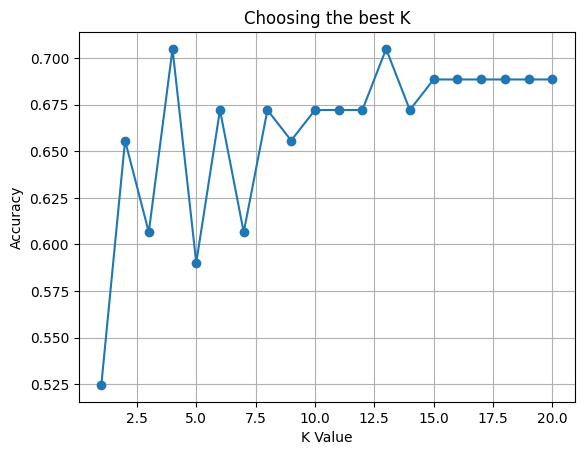

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(k_values, accuracies, marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Choosing the best K")
plt.grid()
plt.show()

## Decision Trees

A Decision Tree is a flowchart of yes/no questions.

<pre>
Is total_bill > 25?
 ├─ Yes → Is size > 3?
 │        ├─ Yes → Smoker
 │        └─ No  → Non-smoker
 └─ No  → Non-smoker
</pre>

- No equations.
- No distances.
- Just decisions.

<img src="Images/Decision Tree.png" height="300px">

### How a tree makes decisions

At each node, the tree asks:

- “Which feature split best separates the classes?”

It chooses:

- A feature

- A threshold

that gives the purest split.

### What does “pure” mean?

A node is pure if:

- Most samples belong to one class

Example:

- 90% smokers → good split

- 50–50 → bad split

Decision Trees try to maximize purity at every split.

📌 Decision Trees do NOT need scaling since they compare values, not distances

### How trees draw decision boundaries

- Axis-aligned (horizontal / vertical)

- Box-like regions

Very different from:

- Straight lines (Logistic Regression)

- Wiggly shapes (KNN)

<img src="Images/decision tree boundary 1.png" height="325px">
<img src="Images/decision tree boundary 2.png" height="325px">

### Strengths vs Weaknesses

| Strengths             | Weaknesses                    |
| --------------------- | ----------------------------- |
| Easy to understand    | Overfits easily               |
| No scaling needed     | Unstable (small data changes) |
| Handles non-linearity | Can grow too deep             |
| Works with mixed data | Needs pruning                 |


### Overfitting problem

Decision Trees love to grow too deep:

Result:

- Training accuracy ≈ 100%

- Test accuracy ❌

We control this with:

- max_depth

- min_samples_split

- min_samples_leaf

## Decision Tree in Code (Classification)

### 1. Prepare data (classification target)

In [21]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

X = df[["total_bill", "size"]]
y = df["smoker"].map({"Yes": 1, "No": 0})


### 2. Train–test split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

### 3. Train a basic Decision Tree (⚠️ will overfit)

In [23]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4. Evaluate

In [24]:
from sklearn.metrics import classification_report

y_pred = tree.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.59      0.61        39
           1       0.33      0.36      0.35        22

    accuracy                           0.51        61
   macro avg       0.48      0.48      0.48        61
weighted avg       0.52      0.51      0.51        61



You’ll often see:

- Very high training accuracy

- Worse test performance

→ classic overfitting

### Control overfitting

| Parameter           | What it controls            |
| ------------------- | --------------------------- |
| `max_depth`         | How deep the tree can grow  |
| `min_samples_split` | Min samples to split a node |
| `min_samples_leaf`  | Min samples in a leaf       |


In [25]:
tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.90      0.76        39
           1       0.50      0.18      0.27        22

    accuracy                           0.64        61
   macro avg       0.58      0.54      0.51        61
weighted avg       0.60      0.64      0.58        61



📌 Usually:

- Slightly lower training accuracy

- Better generalization

### Why these parameters work (intuition)

- max_depth → stops memorization

- min_samples_leaf → avoids tiny noisy splits

This is bias–variance tradeoff again.

### Gini

Gini measures how “mixed” the classes are in a node of a decision tree.

- Low Gini → mostly one class (good)

- High Gini → mixed classes (bad)

Decision Trees choose splits that reduce Gini the most.

For example:

<hr style="opacity:0.1;">

<b>Pure node</b>

```10 smokers, 0 non-smokers```

Gini = 1 − (1<sup>2</sup> + 0<sup>2</sup>) = 0

✅ Perfectly pure

<hr style="opacity:0.1;" width="200px>

<b>Mixed node</b>

```5 smokers, 5 non-smokers```

Gini = 1 − (0.5<sup>2</sup> + 0.5<sup>2</sup>) = 0.5

❌ Very impure

<hr style="opacity:0.1;">



#### Why trees like Gini

Lower Gini = cleaner split

So at each split, the tree asks:

“Which split makes children nodes the purest?”

| Criterion | Meaning  |
| --------- | -------- |
| Gini      | Impurity |
| Entropy   | Disorder |

Both aim for pure nodes.

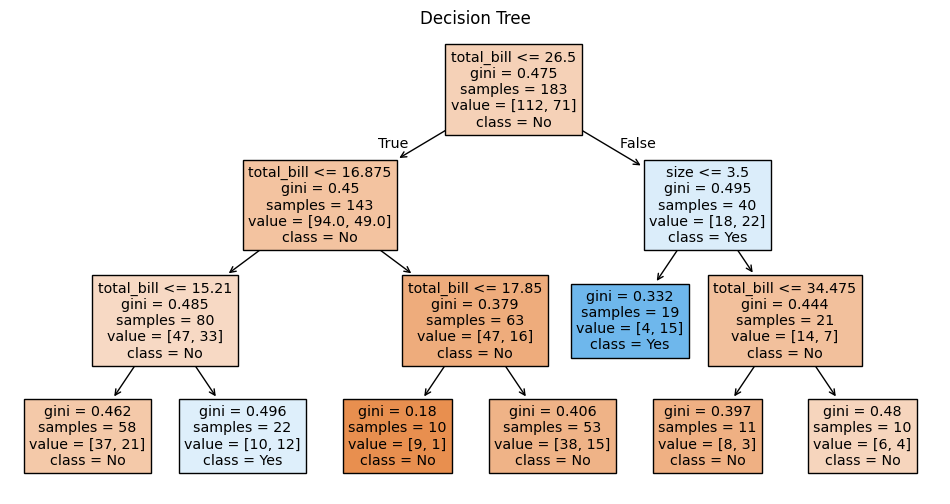

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.title("Decision Tree")
plt.show()
